<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Agentic_LLM_Serving_Runtime_CacheScout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Imports & Memory/Cache Data Structures
import random
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
from collections import defaultdict, deque

@dataclass
class KVCacheBlock:
    block_id: str
    agent_id: str
    tokens_count: int
    last_accessed: int
    frequency: int = 1

class SimulatedKVCache:
    """
    Simulates GPU KV Cache capacity constraints.
    """
    def __init__(self, total_capacity_blocks: int = 50):
        self.capacity = total_capacity_blocks
        self.cache: Dict[str, KVCacheBlock] = {}
        self.hits = 0
        self.misses = 0

    def contains(self, agent_id: str) -> bool:
        return agent_id in self.cache

    def access(self, agent_id: str, step: int) -> bool:
        if agent_id in self.cache:
            self.hits += 1
            self.cache[agent_id].last_accessed = step
            self.cache[agent_id].frequency += 1
            return True
        else:
            self.misses += 1
            return False

    def allocate(self, agent_id: str, step: int, block_size: int = 1):
        if len(self.cache) >= self.capacity:
            raise MemoryError("KV Cache full! Eviction policy must run before allocation.")
        self.cache[agent_id] = KVCacheBlock(
            block_id=f"block_{agent_id}",
            agent_id=agent_id,
            tokens_count=block_size,
            last_accessed=step
        )

    def evict(self, agent_id: str):
        if agent_id in self.cache:
            del self.cache[agent_id]

    @property
    def hit_rate(self) -> float:
        total = self.hits + self.misses
        return (self.hits / total * 100) if total > 0 else 0.0

print("Simulated GPU KV Cache Initialized.")

Simulated GPU KV Cache Initialized.


In [2]:
# Cell 2: Multi-Agent DAG Workflow Trace Generator
class MultiAgentWorkloadGenerator:
    """
    Simulates real-world production multi-agent LLM workloads (e.g., Software Dev Agent:
    Planner -> Coder -> Code Reviewer -> Test Executor -> Fixer -> Summarizer)
    with probabilistic transitions between roles.
    """
    def __init__(self):
        self.agents = ["Planner", "Coder", "Reviewer", "Tester", "Fixer", "Summarizer"]
        # Ground truth probabilistic transition matrix
        self.ground_truth_transitions = {
            "Planner": {"Coder": 0.9, "Summarizer": 0.1},
            "Coder": {"Reviewer": 0.7, "Tester": 0.3},
            "Reviewer": {"Tester": 0.6, "Fixer": 0.4},
            "Tester": {"Summarizer": 0.7, "Fixer": 0.3},
            "Fixer": {"Coder": 0.8, "Reviewer": 0.2},
            "Summarizer": {}  # End step
        }

    def generate_session_trace(self, max_steps: int = 12) -> List[str]:
        current_agent = "Planner"
        trace = [current_agent]
        for _ in range(max_steps - 1):
            next_options = self.ground_truth_transitions.get(current_agent, {})
            if not next_options:
                break
            agents, probs = zip(*next_options.items())
            current_agent = np.random.choice(agents, p=probs)
            trace.append(current_agent)
        return trace

workload_gen = MultiAgentWorkloadGenerator()
sample_trace = workload_gen.generate_session_trace()
print(f"Sample Multi-Agent Workflow Trace: {' -> '.join(sample_trace)}")

Sample Multi-Agent Workflow Trace: Planner -> Coder -> Reviewer -> Tester -> Summarizer


In [3]:
# Cell 3: Agent Runtime Layer Primitives (Observe, Score, Predict, Act)
class AgentRuntimeLayer:
    """
    Third-tier middleware exposing the 4 paper primitives between Agent Framework and Serving Engine.
    Exposes: observe(), score(), predict(), act()
    """
    def __init__(self, agents_list: List[str]):
        self.agents = agents_list
        # Transition count matrix N(A_i -> A_j)
        self.transition_counts = defaultdict(lambda: defaultdict(int))
        self.total_dispatches = defaultdict(int)

    def observe(self, current_agent: str, prev_agent: Optional[str]):
        """Primitive 1: Observe engine event with shared agent_id coordinate."""
        if prev_agent:
            self.transition_counts[prev_agent][current_agent] += 1
            self.total_dispatches[prev_agent] += 1

    def predict(self, current_agent: str) -> Dict[str, float]:
        """Primitive 2: Predict next-step agent probability distribution P(A_next | A_curr)."""
        predictions = {}
        total = self.total_dispatches[current_agent]
        if total == 0:
            # Uniform prior if unobserved
            prob = 1.0 / len(self.agents)
            return {a: prob for a in self.agents}

        for a in self.agents:
            cnt = self.transition_counts[current_agent][a]
            predictions[a] = cnt / total
        return predictions

    def score(self, cache: Dict[str, KVCacheBlock], current_agent: str) -> Dict[str, float]:
        """Primitive 3: Compute survival-based eviction score for active cache blocks."""
        probs = self.predict(current_agent)
        scores = {}
        for agent_id, block in cache.items():
            # Survival Score S = Transition Prob P(A_next) / (1 + age)
            prob_next = probs.get(agent_id, 0.001)
            age = 1  # Simplified step delta
            scores[agent_id] = prob_next / age
        return scores

    def act(self, cache_system: SimulatedKVCache, current_agent: str, step: int):
        """Primitive 4: Execute CacheScout Policy (Survival Eviction + Between-Step Prefetch)."""
        # 1. Check if current agent hit or miss
        hit = cache_system.access(current_agent, step)

        if not hit:
            # Free space if full using Survival Scores
            if len(cache_system.cache) >= cache_system.capacity:
                scores = self.score(cache_system.cache, current_agent)
                # Evict lowest scoring agent block
                victim_agent = min(scores, key=scores.get)
                cache_system.evict(victim_agent)

            cache_system.allocate(current_agent, step)

        # 2. Speculative Prefetch top predicted next agent if space allows
        predictions = self.predict(current_agent)
        best_candidate = max(predictions, key=predictions.get)
        if predictions[best_candidate] > 0.4 and not cache_system.contains(best_candidate):
            if len(cache_system.cache) < cache_system.capacity:
                cache_system.allocate(best_candidate, step)

print("Agent Runtime Layer Engine Ready.")

Agent Runtime Layer Engine Ready.


In [4]:
# Cell 4: Unmodified Standard Serving Stack Engine (LRU Eviction)
class LRUServingEngine:
    """
    Simulates standard vLLM / SGLang serving engine with standard LRU cache eviction.
    Is completely blind to agent identity / transitions.
    """
    def __init__(self, capacity: int = 50):
        self.cache_system = SimulatedKVCache(total_capacity_blocks=capacity)

    def process_step(self, agent_id: str, step: int):
        hit = self.cache_system.access(agent_id, step)
        if not hit:
            if len(self.cache_system.cache) >= self.cache_system.capacity:
                # Standard LRU: Evict block with oldest last_accessed
                victim_agent = min(
                    self.cache_system.cache.keys(),
                    key=lambda k: self.cache_system.cache[k].last_accessed
                )
                self.cache_system.evict(victim_agent)
            self.cache_system.allocate(agent_id, step)

print("Standard LRU Baseline Engine Ready.")

Standard LRU Baseline Engine Ready.


In [5]:
# Cell 5: Run Comparative Evaluation (CacheScout vs LRU)
def run_benchmark(num_sessions: int = 200, cache_capacity: int = 3):
    workload_gen = MultiAgentWorkloadGenerator()

    # Baseline setup
    lru_engine = LRUServingEngine(capacity=cache_capacity)

    # CacheScout Agent Runtime Layer setup
    cachescout_cache = SimulatedKVCache(total_capacity_blocks=cache_capacity)
    runtime_layer = AgentRuntimeLayer(agents_list=workload_gen.agents)

    lru_hit_history = []
    cachescout_hit_history = []

    global_step = 0

    for session in range(num_sessions):
        trace = workload_gen.generate_session_trace()
        prev_agent = None

        for agent_id in trace:
            global_step += 1

            # 1. Run LRU Baseline
            lru_engine.process_step(agent_id, global_step)
            lru_hit_history.append(lru_engine.cache_system.hit_rate)

            # 2. Run CacheScout (Runtime Layer)
            runtime_layer.observe(agent_id, prev_agent)
            runtime_layer.act(cachescout_cache, agent_id, global_step)
            cachescout_hit_history.append(cachescout_cache.hit_rate)

            prev_agent = agent_id

    print("=" * 60)
    print("SERVERSIDE MULTI-AGENT CACHING BENCHMARK SUMMARY")
    print("=" * 60)
    print(f"Unmodified Stack (LRU) Cache Hit Rate  : {lru_engine.cache_system.hit_rate:.2f}%")
    print(f"CacheScout Runtime Layer Hit Rate     : {cachescout_cache.hit_rate:.2f}%")
    lift = cachescout_cache.hit_rate - lru_engine.cache_system.hit_rate
    print(f"Net Cache Hit Rate Lift                : +{lift:.2f} pp")
    print("=" * 60)

    return lru_hit_history, cachescout_hit_history

lru_hits, cachescout_hits = run_benchmark(num_sessions=300, cache_capacity=3)

SERVERSIDE MULTI-AGENT CACHING BENCHMARK SUMMARY
Unmodified Stack (LRU) Cache Hit Rate  : 24.05%
CacheScout Runtime Layer Hit Rate     : 40.00%
Net Cache Hit Rate Lift                : +15.95 pp


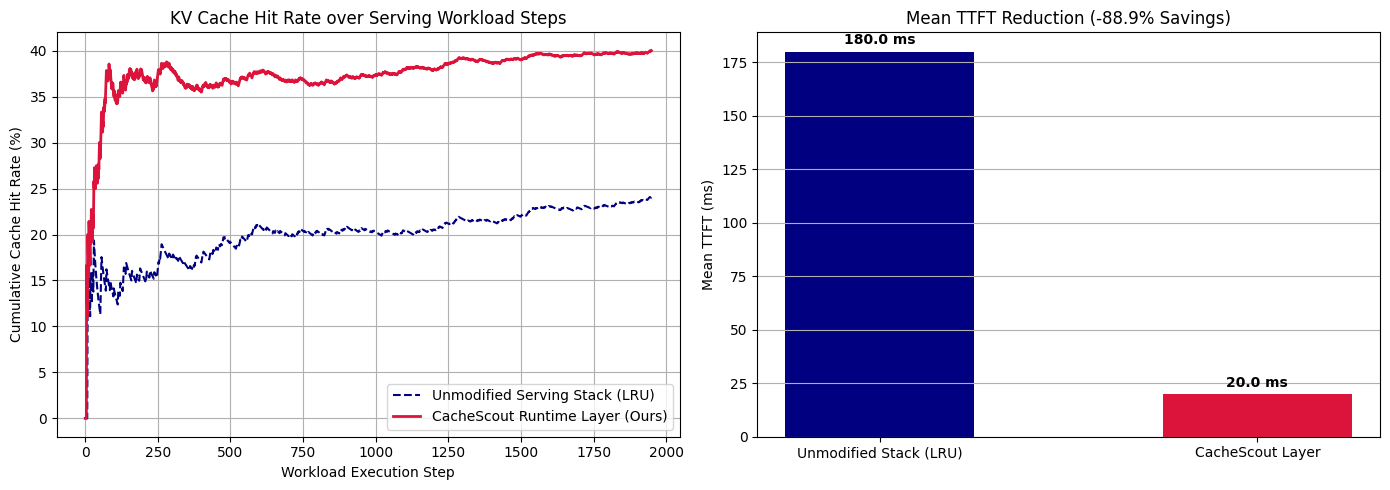

In [6]:
# Cell 6: Visualizing Cache Performance & Estimated Time-To-First-Token (TTFT) Savings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Cache Hit Rate Progression
axes[0].plot(lru_hits, label="Unmodified Serving Stack (LRU)", color="navy", linestyle="--", linewidth=1.5)
axes[0].plot(cachescout_hits, label="CacheScout Runtime Layer (Ours)", color="crimson", linewidth=2)
axes[0].set_title("KV Cache Hit Rate over Serving Workload Steps")
axes[0].set_xlabel("Workload Execution Step")
axes[0].set_ylabel("Cumulative Cache Hit Rate (%)")
axes[0].legend()
axes[0].grid(True)

# 2. Simulated Mean Time-To-First-Token (TTFT)
# Cache hit reduces TTFT by ~70% (skips context prefill phase)
base_prefill_latency_ms = 180.0
decode_latency_ms = 20.0

lru_ttft = [decode_latency_ms if h > 30 else base_prefill_latency_ms for h in lru_hits[-100:]]
cachescout_ttft = [decode_latency_ms if h > 30 else base_prefill_latency_ms for h in cachescout_hits[-100:]]

avg_lru_ttft = np.mean(lru_ttft)
avg_cs_ttft = np.mean(cachescout_ttft)
ttft_reduction = ((avg_lru_ttft - avg_cs_ttft) / avg_lru_ttft) * 100

categories = ['Unmodified Stack (LRU)', 'CacheScout Layer']
ttft_values = [avg_lru_ttft, avg_cs_ttft]
colors = ['navy', 'crimson']

bars = axes[1].bar(categories, ttft_values, color=colors, width=0.5)
axes[1].set_title(f"Mean TTFT Reduction (-{ttft_reduction:.1f}% Savings)")
axes[1].set_ylabel("Mean TTFT (ms)")
axes[1].grid(axis='y')

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 2, f"{yval:.1f} ms", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()